In [1]:
from IPython import get_ipython
from IPython.display import display

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.7 MB/s eta 0:00:00


In [5]:
import os
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.svm import SVR
from skopt import gp_minimize
from skopt.space import Real, Categorical, Integer
from scipy.stats import zscore
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from scipy.stats import zscore

In [63]:
# Load dataset
features_train = pd.read_csv("/content/drive/MyDrive/Kuliah/Proposal/New/dengue_features_train.csv")
labels_train = pd.read_csv("/content/drive/MyDrive/Kuliah/Proposal/New/dengue_labels_train.csv")
features_test = pd.read_csv("/content/drive/MyDrive/Kuliah/Proposal/New/dengue_features_test.csv")

In [64]:
# Store 'week_start_date' separately for each city
week_start_date_train_sj = features_train.loc[features_train["city"] == "sj", 'week_start_date'].copy()
week_start_date_train_iq = features_train.loc[features_train["city"] == "iq", 'week_start_date'].copy()
week_start_date_test = features_test['week_start_date'].copy()

In [65]:
# Drop 'week_start_date' column from features dataframes
features_train.drop(columns=["week_start_date"], inplace=True)
features_test.drop(columns=["week_start_date"], inplace=True)

In [66]:
# Merge features and labels
train_data = features_train.merge(labels_train, on=["city", "year", "weekofyear"])

In [67]:
# Split dataset by city
sj_train = train_data[train_data["city"] == "sj"].drop(columns=["city"])
iq_train = train_data[train_data["city"] == "iq"].drop(columns=["city"])
features_test_sj = features_test[features_test["city"] == "sj"].drop(columns=['city'])
features_test_iq = features_test[features_test["city"] == "iq"].drop(columns=['city'])

Preprocessing

In [68]:
## Data Preprocessing

def preprocess_data(df_train, df_test, city_name):
    """Handles missing values, outlier detection (based on train), and standardization."""

    # Handle missing values (fill with median from training data)
    median_values = df_train.median(numeric_only=True)
    df_train.fillna(median_values, inplace=True)
    df_test.fillna(median_values, inplace=True) # Use training median for test data

    # Outlier Detection and Removal (based on training data)
    # Calculate Z-scores for training data (excluding 'total_cases' if it's the target)
    features_for_outlier_detection = df_train.drop(columns=['total_cases'] if 'total_cases' in df_train.columns else [], errors='ignore')
    z_scores_train = np.abs(zscore(features_for_outlier_detection))
    outliers_train_mask = (z_scores_train > 3).any(axis=1)
    outlier_rows_train = df_train.index[outliers_train_mask].tolist()
    print(f"Jumlah data dengan outlier di {city_name} train: {len(outlier_rows_train)}")

    # **Remove outliers from the training data**
    df_train_cleaned = df_train.drop(outlier_rows_train)
    print(f"Jumlah data train setelah outlier removal di {city_name}: {len(df_train_cleaned)}")


    # Separate features and target from the CLEANED training data
    if 'total_cases' in df_train_cleaned.columns:
        X_train = df_train_cleaned.drop(columns=['total_cases', 'year'], errors='ignore') # Drop year as it might not be a good feature for SVR/PCA
        y_train = df_train_cleaned['total_cases']
    else:
        X_train = df_train_cleaned.drop(columns=['year'], errors='ignore')
        y_train = None # Should not happen for train data

    X_test = df_test.drop(columns=['year'], errors='ignore') # Drop year from test data

    # Apply StandardScaler (fit on CLEANED train, transform CLEANED train and test)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test) # Use the same scaler fitted on train

    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

    # Apply PCA (fit on CLEANED train, transform CLEANED train and test)
    pca = PCA(n_components=12) # Choose number of components
    X_train_pca = pca.fit_transform(X_train_scaled_df)
    X_test_pca = pca.transform(X_test_scaled_df) # Use the same PCA fitted on train

    X_train_pca_df = pd.DataFrame(X_train_pca, index=X_train.index)
    X_test_pca_df = pd.DataFrame(X_test_pca, index=X_test.index)

    return X_train_pca_df, y_train, X_test_pca_df

In [69]:
# Preprocess data for San Juan and Iquitos
X_train_sj_pca, y_train_sj, X_test_sj_pca = preprocess_data(sj_train, features_test_sj.copy(), "San Juan")
X_train_iq_pca, y_train_iq, X_test_iq_pca = preprocess_data(iq_train, features_test_iq.copy(), "Iquitos")


print("\nProcessed data shapes:")
print("San Juan Train Features (PCA):", X_train_sj_pca.shape)
print("San Juan Train Target:", y_train_sj.shape)
print("San Juan Test Features (PCA):", X_test_sj_pca.shape)
print("Iquitos Train Features (PCA):", X_train_iq_pca.shape)
print("Iquitos Train Target:", y_train_iq.shape)
print("Iquitos Test Features (PCA):", X_test_iq_pca.shape)

Jumlah data dengan outlier di San Juan train: 87
Jumlah data train setelah outlier removal di San Juan: 849
Jumlah data dengan outlier di Iquitos train: 51
Jumlah data train setelah outlier removal di Iquitos: 469

Processed data shapes:
San Juan Train Features (PCA): (849, 12)
San Juan Train Target: (849,)
San Juan Test Features (PCA): (260, 12)
Iquitos Train Features (PCA): (469, 12)
Iquitos Train Target: (469,)
Iquitos Test Features (PCA): (156, 12)


Model Training and Evaluation

In [70]:
def train_and_evaluate_svr(X_train, y_train, X_test, y_test, city_name):
    """Trains and evaluates a basic SVR model."""
    svr_model = SVR()

    start_time = time.time()
    svr_model.fit(X_train, y_train)
    end_time = time.time()
    execution_time = end_time - start_time

    y_pred = svr_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n--- Basic SVR Results ({city_name}) ---")
    print(f"Mean Absolute Error: {mae}")
    print(f"Root Mean Squared Error: {rmse}")
    print(f"Training Time: {execution_time:.4f} seconds")

    return svr_model # Return the trained model

In [71]:
def tune_and_evaluate_svr(X_train, y_train, X_test, y_test, city_name):
    """Performs GridSearchCV for SVR tuning and evaluates the best model."""
    param_grid_rbf = {
        'C': [0.01, 0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1],
        'kernel': ['rbf'],
        'epsilon': [0.001, 0.01, 0.1, 1, 10]
    }

    svr_model = SVR()
    grid_search = GridSearchCV(estimator=svr_model, param_grid=param_grid_rbf,
                              cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

    print(f"\nTuning SVR with GridSearchCV ({city_name})...")
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    end_time = time.time()
    execution_time = end_time - start_time

    best_svr_model = grid_search.best_estimator_
    y_pred = best_svr_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n--- GridSearchCV SVR Results ({city_name}) ---")
    print(f"Best Hyperparameters: {grid_search.best_params_}")
    print(f"Mean Absolute Error: {mae}")
    print(f"Root Mean Squared Error: {rmse}")
    print(f"Tuning and Evaluation Time: {execution_time:.4f} seconds")

    return best_svr_model # Return the best trained model

In [72]:
# Split training data for validation (for evaluation metrics)
X_train_sj_split, X_test_sj_split, y_train_sj_split, y_test_sj_split = train_test_split(
    X_train_sj_pca, y_train_sj, test_size=0.2, random_state=42)
X_train_iq_split, X_test_iq_split, y_train_iq_split, y_test_iq_split = train_test_split(
    X_train_iq_pca, y_train_iq, test_size=0.2, random_state=42)

In [73]:
# Train and evaluate basic SVR
basic_svr_sj = train_and_evaluate_svr(X_train_sj_split, y_train_sj_split, X_test_sj_split, y_test_sj_split, "San Juan (Basic)")
basic_svr_iq = train_and_evaluate_svr(X_train_iq_split, y_train_iq_split, X_test_iq_split, y_test_iq_split, "Iquitos (Basic)")


--- Basic SVR Results (San Juan (Basic)) ---
Mean Absolute Error: 21.419730976129905
Root Mean Squared Error: 47.93139601354305
Training Time: 0.0398 seconds

--- Basic SVR Results (Iquitos (Basic)) ---
Mean Absolute Error: 6.779105588388328
Root Mean Squared Error: 14.889522816160925
Training Time: 0.0132 seconds


In [74]:
# Tune and evaluate SVR with GridSearchCV
tuned_svr_sj = tune_and_evaluate_svr(X_train_sj_split, y_train_sj_split, X_test_sj_split, y_test_sj_split, "San Juan (Tuned)")
tuned_svr_iq = tune_and_evaluate_svr(X_train_iq_split, y_train_iq_split, X_test_iq_split, y_test_iq_split, "Iquitos (Tuned)")


Tuning SVR with GridSearchCV (San Juan (Tuned))...

--- GridSearchCV SVR Results (San Juan (Tuned)) ---
Best Hyperparameters: {'C': 100, 'epsilon': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Mean Absolute Error: 20.062086188931804
Root Mean Squared Error: 45.81128595773383
Tuning and Evaluation Time: 20.4623 seconds

Tuning SVR with GridSearchCV (Iquitos (Tuned))...

--- GridSearchCV SVR Results (Iquitos (Tuned)) ---
Best Hyperparameters: {'C': 1, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}
Mean Absolute Error: 6.835315155343442
Root Mean Squared Error: 14.985738081110085
Tuning and Evaluation Time: 6.2439 seconds


Prediction on Test Data

In [75]:
# Make predictions on the actual test data using the models trained on the FULL training data
# For basic SVR, re-train on the full training data (not the split version)
basic_svr_sj.fit(X_train_sj_pca, y_train_sj)
basic_svr_iq.fit(X_train_iq_pca, y_train_iq)

# For tuned SVR, the `tuned_svr_sj` and `tuned_svr_iq` objects are already the best models
# found by GridSearchCV, fitted on the full training data (X_train_sj_pca/X_train_iq_pca).

pred_sj_no_tune = basic_svr_sj.predict(X_test_sj_pca)
pred_iq_no_tune = basic_svr_iq.predict(X_test_iq_pca)

pred_sj_grid_tune = tuned_svr_sj.predict(X_test_sj_pca)
pred_iq_grid_tune = tuned_svr_iq.predict(X_test_iq_pca)

# Ensure predictions are non-negative integers
pred_sj_no_tune = np.maximum(0, np.round(pred_sj_no_tune)).astype(int)
pred_iq_no_tune = np.maximum(0, np.round(pred_iq_no_tune)).astype(int)
pred_sj_grid_tune = np.maximum(0, np.round(pred_sj_grid_tune)).astype(int)
pred_iq_grid_tune = np.maximum(0, np.round(pred_iq_grid_tune)).astype(int)


# Create submission DataFrames (using the original test features for city/year/weekofyear)
# Combine predictions for SJ and IQ in the correct order based on the original test data
submission_df_no_tune = features_test[['city', 'year', 'weekofyear']].copy()
submission_df_grid_tune = features_test[['city', 'year', 'weekofyear']].copy()

# Assign predictions to the correct rows based on the original test set index
submission_df_no_tune.loc[features_test['city'] == 'sj', 'total_cases'] = pred_sj_no_tune
submission_df_no_tune.loc[features_test['city'] == 'iq', 'total_cases'] = pred_iq_no_tune

submission_df_grid_tune.loc[features_test['city'] == 'sj', 'total_cases'] = pred_sj_grid_tune
submission_df_grid_tune.loc[features_test['city'] == 'iq', 'total_cases'] = pred_iq_grid_tune

# Save predictions
output_dir = "/content/drive/MyDrive/Kuliah/Proposal/HASIL"
os.makedirs(output_dir, exist_ok=True) # Create directory if it doesn't exist

submission_df_no_tune.to_csv(os.path.join(output_dir, "pca_svr_no_tuning_submission.csv"), index=False)
submission_df_grid_tune.to_csv(os.path.join(output_dir, "pca_svr_grid_tuning_submission.csv"), index=False)

print("\nPrediction files saved:")
print(os.path.join(output_dir, "pca_svr_no_tuning_submission.csv"))
print(os.path.join(output_dir, "pca_svr_grid_tuning_submission.csv"))


Prediction files saved:
/content/drive/MyDrive/Kuliah/Proposal/HASIL/pca_svr_no_tuning_submission.csv
/content/drive/MyDrive/Kuliah/Proposal/HASIL/pca_svr_grid_tuning_submission.csv


In [76]:
## Plotting

def plot_predictions(city, results_dir, week_start_date_test_orig):
    """Plots predicted dengue cases from different submission files."""
    fig, ax = plt.subplots(figsize=(30, 9))

    colors = {"no_tuning": "red", "grid_tuning": "green"}

    # Iterate through potential submission files
    for filename in os.listdir(results_dir):
        if filename.endswith(".csv") and filename.startswith("pca_svr_"):
            try:
                parts = filename.split('_')
                if len(parts) >= 4 and parts[0] == 'pca' and parts[1] == 'svr':
                    method = '_'.join(parts[2:-1]) # This should give 'no_tuning' or 'grid_tuning'
                else:
                     continue # Skip files that don't match the expected pattern
            except IndexError:
                continue

            if method not in colors:
                print(f"Warning: Color not defined for method: {method}. Skipping plotting for this file.")
                continue

            color = colors[method]
            filepath = os.path.join(results_dir, filename)
            test_data = pd.read_csv(filepath)

            city_test_data = test_data[test_data["city"] == city].copy()

            # Use the original week_start_date_test to get the correct dates
            # Align based on the index of the filtered data frame to the original test data frame
            original_indices = city_test_data.index
            city_test_data['week_start_date'] = pd.to_datetime(week_start_date_test_orig.loc[original_indices])

            ax.plot(city_test_data['week_start_date'], city_test_data['total_cases'],
                     linestyle='--', label=f'Predicted ({method})', color=color)

    # Setting x-axis limits based on city (assuming test data period)
    if city == 'iq':
         ax.set_xlim([pd.to_datetime('2010-07-01'), pd.to_datetime('2013-12-31')]) # Test data start/end
    elif city == 'sj':
         ax.set_xlim([pd.to_datetime('2008-04-29'), pd.to_datetime('2013-05-20')]) # Test data start/end

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3)) # Show quarterly ticks

    ax.set_xlabel("Date")
    ax.set_ylabel("Predicted Cases")
    ax.set_title(f"Predicted Dengue Cases in {city.upper()}")
    ax.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    fig.autofmt_xdate()
    plt.show()

In [77]:
def plot_cases(city, train_data, submission_files_dict, week_start_date_train_orig, week_start_date_test_orig):
    """Plots actual training cases and predicted test cases."""
    train_data = train_data.copy() # Avoid modifying the original DataFrame
    fig, ax = plt.subplots(figsize=(30, 9))

    # Add week_start_date to train_data for plotting
    train_data['week_start_date'] = pd.to_datetime(week_start_date_train_orig.loc[train_data.index])

    # Plot actual cases from training data
    ax.plot(train_data['week_start_date'], train_data['total_cases'],
             linestyle='-', label='Actual Cases (Train)', color='blue')

    # Plot predicted cases from submission files
    colors = {"no_tuning": "red", "grid_tuning": "green"}
    for method, filepath in submission_files_dict.items():
        if method not in colors:
            print(f"Warning: Color not defined for method: {method}. Skipping plotting for this file.")
            continue

        test_data = pd.read_csv(filepath)
        city_test_data = test_data[test_data["city"] == city].copy()

        # Use the original week_start_date_test to get the correct dates
        original_indices = city_test_data.index
        city_test_data['week_start_date'] = pd.to_datetime(week_start_date_test_orig.loc[original_indices])


        ax.plot(city_test_data['week_start_date'], city_test_data['total_cases'],
                 linestyle='--', label=f'Predicted ({method})', color=colors[method])

    # Setting x-axis limits based on the full timeline (train + test)
    all_dates = pd.concat([train_data['week_start_date'], city_test_data['week_start_date']]).unique()
    min_date = pd.to_datetime(all_dates).min()
    max_date = pd.to_datetime(all_dates).max()
    ax.set_xlim([min_date, max_date])


    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

    ax.set_xlabel("Date")
    ax.set_ylabel("Total Cases")
    ax.set_title(f"Dengue Cases in {city.upper()}")
    ax.legend()

    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    fig.autofmt_xdate()
    plt.show()

Plotting Predictions for Test Period:


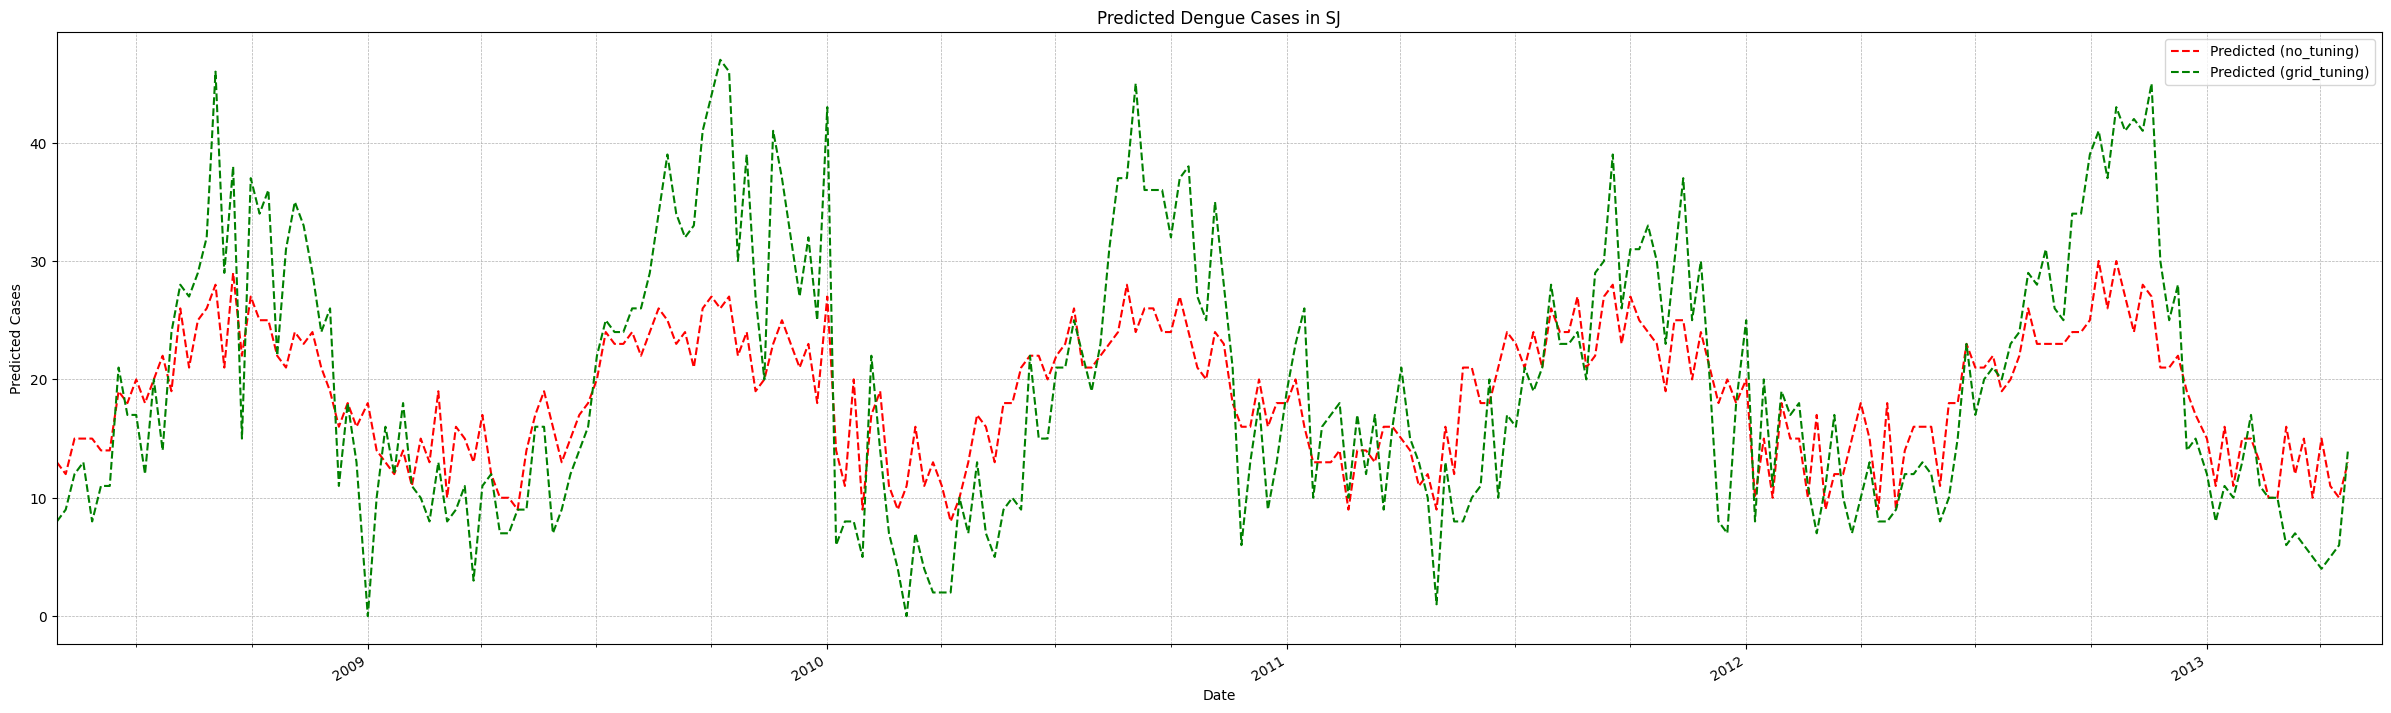

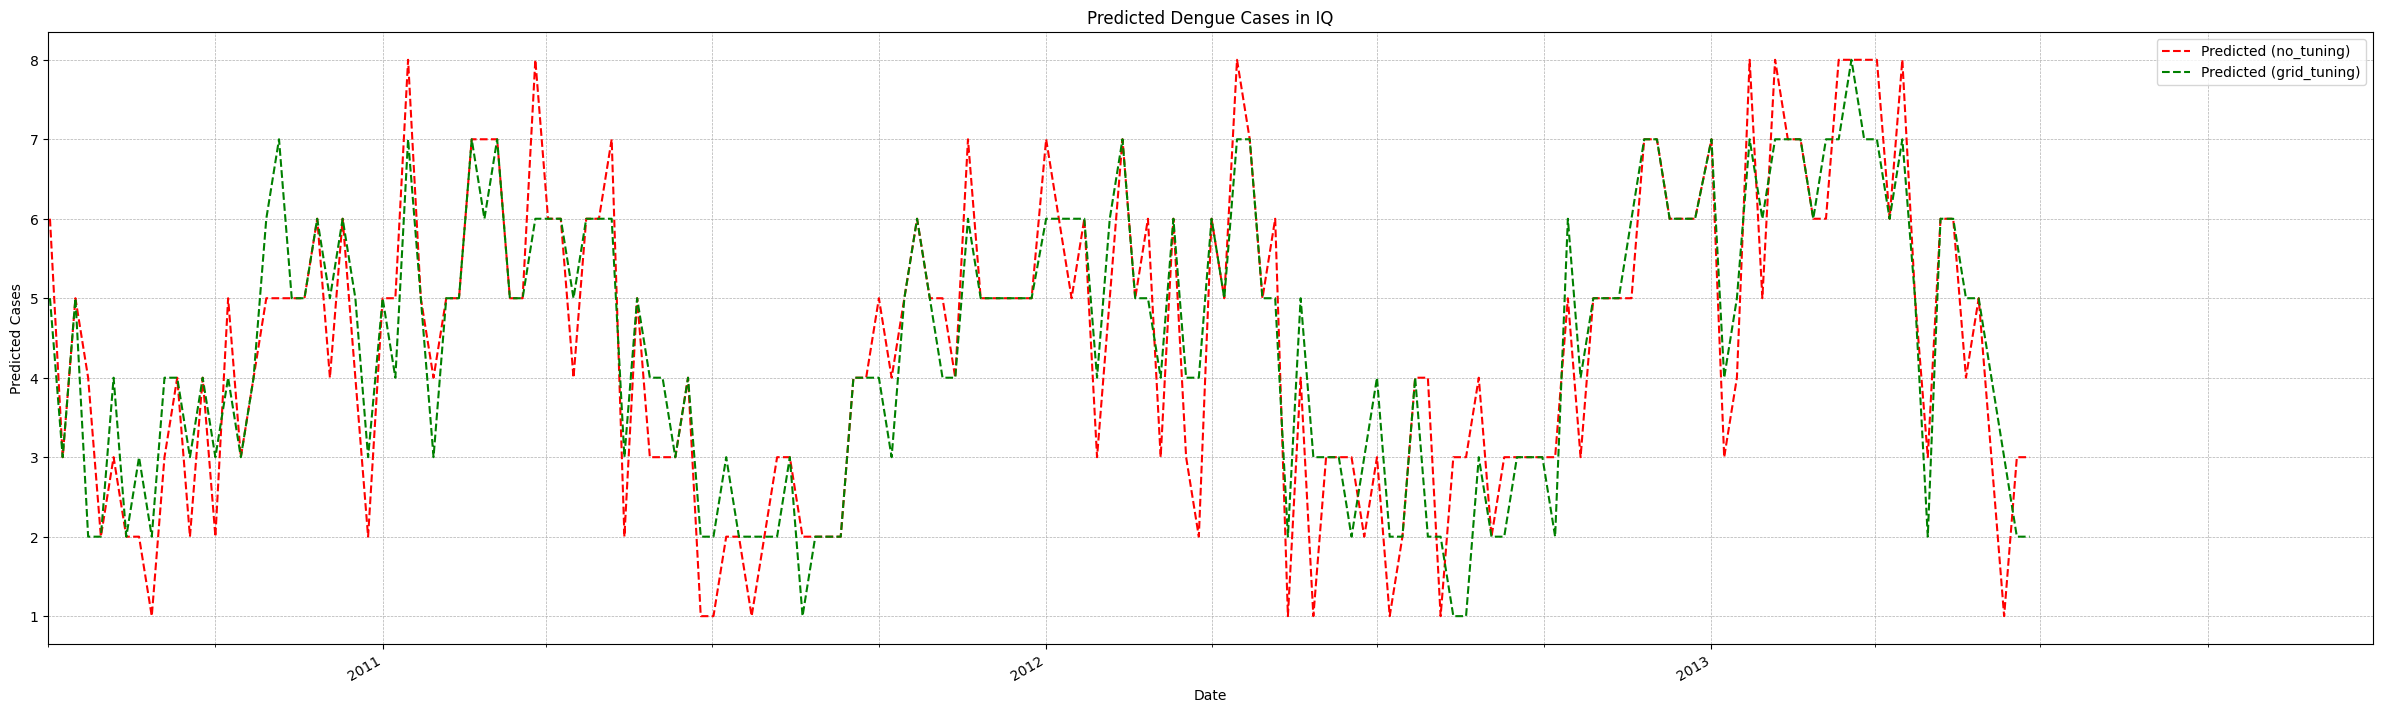


Plotting Actual (Train) vs Predicted (Test):


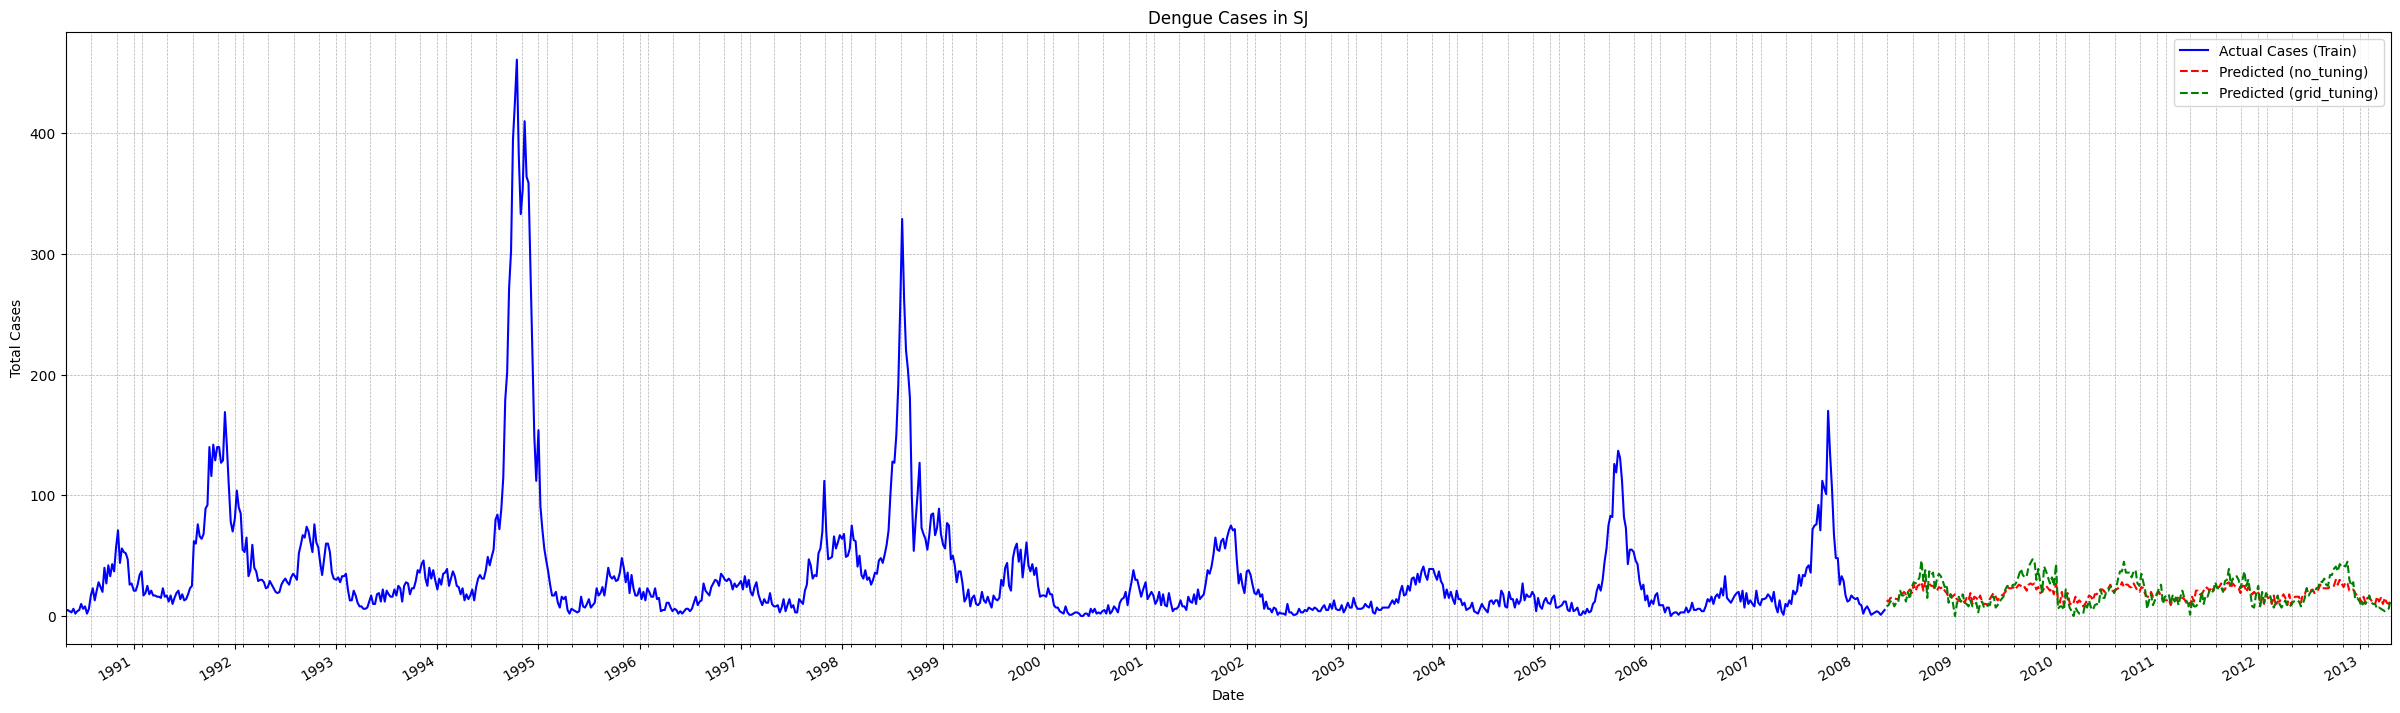

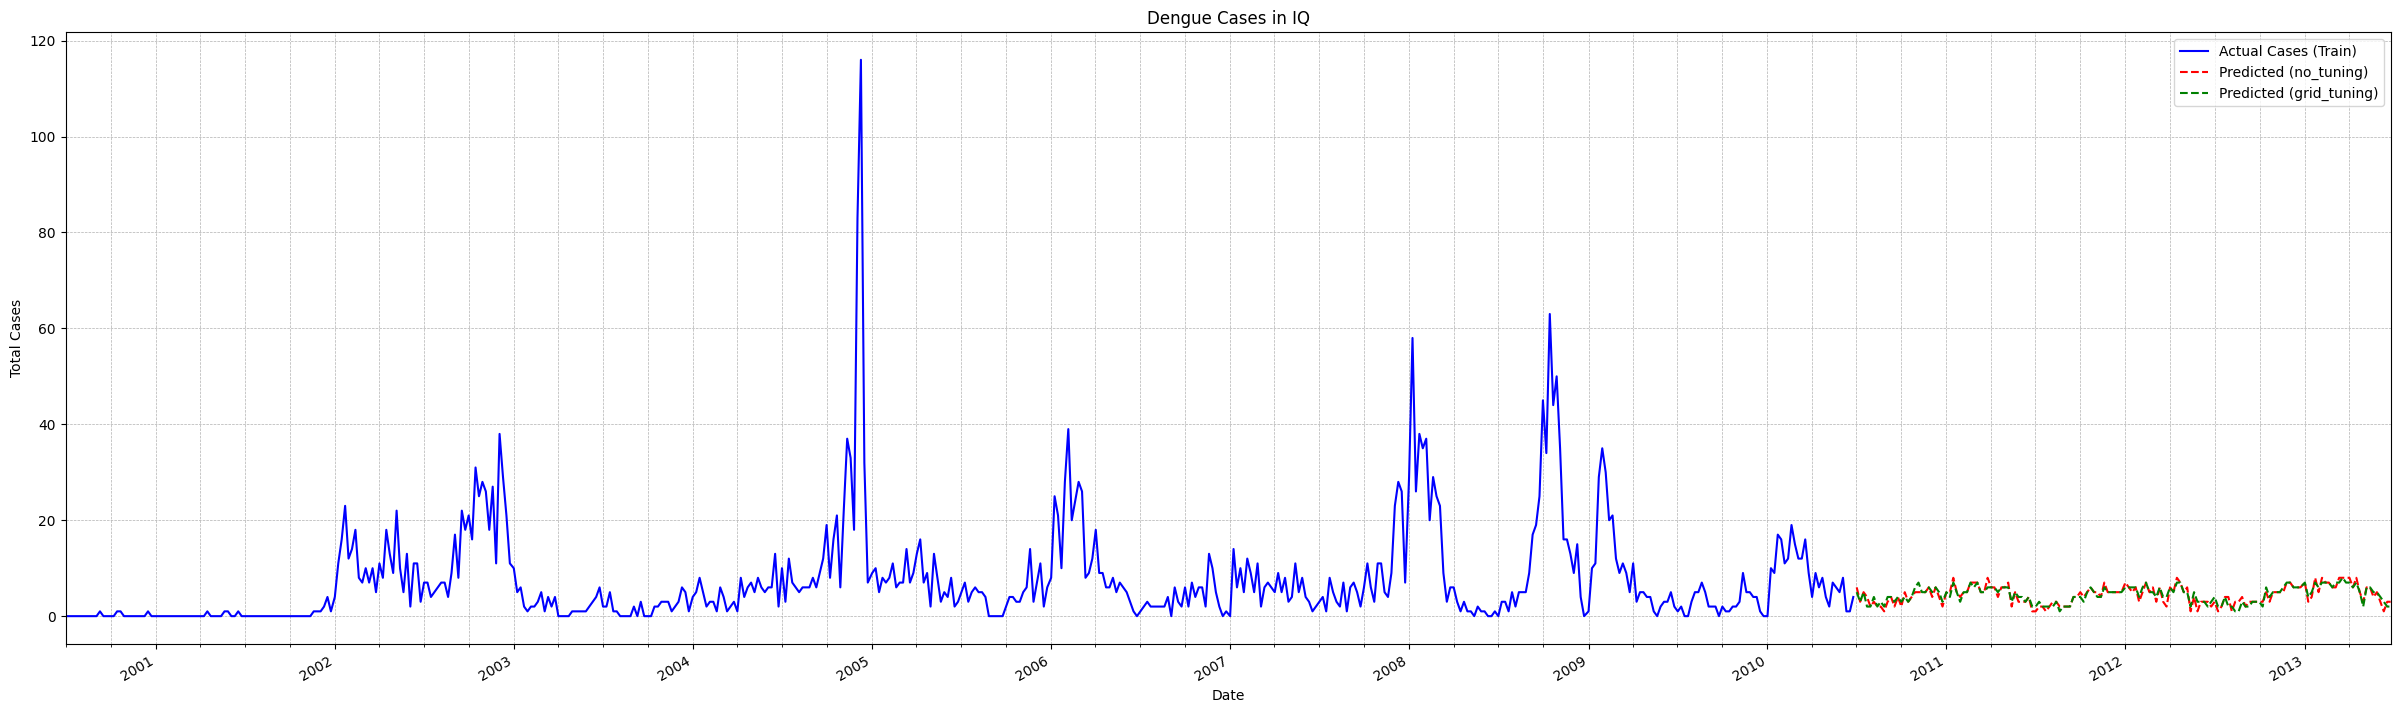

In [78]:
# Define submission file paths
submission_files = {
    "no_tuning": "/content/drive/MyDrive/Kuliah/Proposal/HASIL/pca_svr_no_tuning_submission.csv",
    "grid_tuning": "/content/drive/MyDrive/Kuliah/Proposal/HASIL/pca_svr_grid_tuning_submission.csv",
}

# Plot predictions only for test period
print("Plotting Predictions for Test Period:")
plot_predictions('sj', "/content/drive/MyDrive/Kuliah/Proposal/HASIL", week_start_date_test)
plot_predictions('iq', "/content/drive/MyDrive/Kuliah/Proposal/HASIL", week_start_date_test)

# Plot actual training cases and predicted test cases
print("\nPlotting Actual (Train) vs Predicted (Test):")
plot_cases("sj", sj_train, submission_files, week_start_date_train_sj, week_start_date_test)
plot_cases("iq", iq_train, submission_files, week_start_date_train_iq, week_start_date_test)